Tenemos el código siguiente para simular el sistema Solar utilizando el método de Verlet para resolver las ecuaciones de movimiento. El código está escrito en Python y utiliza la biblioteca NumPy para manejar los cálculos numéricos.
Las condiciones se establecen tras las definiciones de las funciones que se utilizaran en el código.

In [2]:
def accel(m, r):
    """
    Función para calcular la aceleración tras cada paso h dados un vector de masas y la matriz 2x10 de posiciones
    """
    a[:,:]=0
    for i in range(10):
        for j in range(10):
            if i!=j:
                a[0,i]+=-(m[j]*(r[0,i]-r[0,j]))/(np.sqrt((r[0,i]-r[0,j])**2+(r[1,i]-r[1,j])**2)**3)
                a[1,i]+=-(m[j]*(r[1,i]-r[1,j]))/(np.sqrt((r[0,i]-r[0,j])**2+(r[1,i]-r[1,j])**2)**3)
    return a

def waux(v, a, h):
    w=np.zeros((2,10))
    """
    Función para calcular la matriz auxiliar 2x10 w tras cada paso h dados la matriz 2x10 de velocidades, la matriz 2x10 de aceleraciones y el propio paso temporal h
    """
    for i in range(10):
        w[:,i]=v[:,i]+h/2*a[:,i]
    return w

def vel(a, w, h):
    v=np.zeros((2,10))
    """
    Función para calcular la aceleración tras cada paso h dados la matriz 2x10 de aceleraciones, la matriz 2x10 auxiliar w y el propio paso temporal h
    """
    v=np.zeros((2,10))
    for i in range(10):
        v[:,i]=w[:,i]+h/2*a[:,i]
    return v

def pos(r, v, a, h):
    """
    Función para calcular las posiciones tras cada paso h dados la matriz 2x10 de posiciones, la matriz 2x10 de velocidades, la matriz 2x10 de aceleraciones y el propio paso 
    temporal h
    """
    for i in range(10):
        r[:,i]+=h*v[:,i]+h**2/2*a[:,i]
    return r

def Energias(m, r, v):
    """
    Función para calcular la energía total del sistema tras cada paso h dados el vector de masas, la matriz 2x10 de posiciones y la matriz 2x10 de velocidades
    """
    Ec=0
    Ep=0
    for i in range(10):
        Ec+=0.5*(m[i])*(v[0,i]**2+v[1,i]**2)
        for j in range(10):
            if i!=j:
                Ep+=-(m[i])/(np.sqrt(r[0,i]**2+r[1,i]**2))
    Et=Ec+Ep
    return Ec, Ep, Et

###############################################################################################################################################################################
###############################################################################################################################################################################
###############################################################################################################################################################################

import numpy as np

G=6.67392e-11           #Constante gravitación universal en N*m**2/kg**2
c=1.496e11              #Distancia Tierra-Sol en m
MS=1.99e30              #Masa solar en kg

posi=open('planetas_posiciones.txt','w')
cin=open('ec.txt','w')
pot=open('ep.txt','w')
tot=open('et.txt','w')
periodo=open('periodos.txt','w')
momento=open('momentos.txt','w')

"""
Inicializamos el vector masas reescalado
"""
m=np.zeros(10)          
m[0]=1                  #Sol (subíndice 0)
m[1]=0.33e24/MS         #Mercurio (subíndice 1)
m[2]=4.87e24/MS         #Venus (subíndice 2)
m[3]=5.97e24/MS         #Tierra (subíndice 3)
m[4]=0.642e24/MS        #Marte (subíndice 4)
m[5]=1899e24/MS         #Júpiter (subíndice 5)
m[6]=568e24/MS          #Saturno (subíndice 6)
m[7]=86.8e24/MS         #Urano (subíndice 7)
m[8]=102e24/MS          #Neptuno (subíndice 8)
m[9]=0.0125e24/MS       #Plutón (subíndice 9)

"""
Matriz posiciones reescalada: con filas acordes a coordenadas x e y de cada columna/planeta y colocamos estas posiciones en una matriz 2x10
"""
r=np.zeros((2,10)) 
r[0,0]=1e-15
r[0,1]=57.9e9/c
r[0,2]=108.2e9/c
r[0,3]=1
r[0,4]=227.9e9/c
r[0,5]=778.6e9/c
r[0,6]=1433.5e9/c
r[0,7]=2872.5e9/c
r[0,8]=4495.1e9/c
r[0,9]=5870e9/c
r[1,:]=0

for i in range(10):
  posi.write(f'{r[0,i]}\t{r[1,i]}\t')
posi.write("\n")

"""
Matriz velocidad reescalada: con filas acordes a componentes v_x y v_y de cada columna/planeta

Vector auxiliar w
"""
v=np.zeros((2,10)) 
v[0,:]=0
v[1,0]=1e-50
v[1,1]=(47.9e3/c)/(np.sqrt((G*MS)/c**3))
v[1,2]=(35e3/c)/(np.sqrt((G*MS)/c**3))
v[1,3]=(29.8e3/c)/(np.sqrt((G*MS)/c**3))
v[1,4]=(24.1e3/c)/(np.sqrt((G*MS)/c**3))
v[1,5]=(13.1e3/c)/(np.sqrt((G*MS)/c**3))
v[1,6]=(9.7e3/c)/(np.sqrt((G*MS)/c**3))
v[1,7]=(6.8e3/c)/(np.sqrt((G*MS)/c**3))
v[1,8]=(5.4e3/c)/(np.sqrt((G*MS)/c**3))
v[1,9]=(4.7e3/c)/(np.sqrt((G*MS)/c**3))

w=np.zeros((2,10))

"""
Matriz aceleración: con filas acordes a componentes a_x y a_y de cada columna/planeta
"""
a=np.zeros((2,10)) 

"""
Indicamos el paso temporal h  y creamos un vector para guardar más tarde los periodos
"""
h=0.0001
T=np.zeros(10)

"""
Calculamos la energía total en el instante 0, la energía cinética, la energíapotencial y la aceleración que sufre cada planeta por la acción gravitatoria de los otros cuerpos
"""
EC, EP, ET=Energias(m, r, v)
cin.write(f'{0}\t{EC}\n')
pot.write(f'{0}\t{EP}\n')
tot.write(f'{0}\t{ET}\n')

a=accel(m, r)

#T=periodo(r)
#print(T)

"""
Variable booleana auxiliar para calcular los periodos y variable auxiliar para guardar los datos cada cierto número de pasos
"""
pasaprimercuadrante=np.array([False,False,False,False,False,False,False,False,False,False],dtype=bool)
vez=np.ones(10)

pasos=0

"""
Empezamos los cálculos
"""
for t in np.arange(0, 5e3, h):
    print(t)
    """
    Este bucle nos permitirá recoger de forma aproximada los periodos de los planetas
    """
    for i in range(10):
        if r[0,i]<=0:
            pasaprimercuadrante[i]=True
        if r[0,i]>0 and pasaprimercuadrante[i]==True and vez[i]==1:
            if r[1,i]>=0: 
                T[i]=58.1*(2*t-h)/2
                vez[i]+=1

    """
    Recalculamos las posiciones y la matriz auxiliar w
    """
    r=pos(r, v, a, h)
    w=waux(v, a, h)
    
    """
    Recalculamos la aceleración según las nuevas posiciones (posible mejora en términos de memoria)
    """
    a=accel(m, r)
    
    """
    Con las aceleraciones nuevas, recalculamos las velocidades
    """
    v=vel(a, w, h)
    
    """
    Recalculamos las energías
    """
    EC, EP, ET=Energias(m, r, v)

    """
    Aumentamos la variable para contar y guardamos las posiciones cada x pasos
    """
    pasos+=1
    if pasos%5000==0:
        for i in range(10):
            posi.write(f'{r[0,i]}\t{r[1,i]}\t')
            momento.write(f'{m[i]*(r[0,i]*v[1,i]-r[1,i]*v[0,i])}\t')
        cin.write(f'{t+h}\t{EC}\n')
        pot.write(f'{t+h}\t{EP}\n')
        tot.write(f'{t+h}\t{ET}\n')
        posi.write("\n")
        momento.write("\n")
for i in range(10):
    periodo.write(f'{T[i]}\t')
posi.close()
cin.close()
pot.close()
tot.close()
momento.close()
periodo.close()

0.0
0.0001
0.0002
0.00030000000000000003
0.0004
0.0005
0.0006000000000000001
0.0007
0.0008
0.0009000000000000001
0.001
0.0011
0.0012000000000000001
0.0013000000000000002
0.0014
0.0015
0.0016
0.0017000000000000001
0.0018000000000000002
0.0019
0.002
0.0021000000000000003
0.0022
0.0023
0.0024000000000000002
0.0025
0.0026000000000000003
0.0027
0.0028
0.0029000000000000002
0.003
0.0031000000000000003
0.0032
0.0033
0.0034000000000000002
0.0035
0.0036000000000000003
0.0037
0.0038
0.0039000000000000003
0.004
0.0041
0.004200000000000001
0.0043
0.0044
0.0045000000000000005
0.0046
0.0047
0.0048000000000000004
0.0049
0.005
0.0051
0.005200000000000001
0.0053
0.0054
0.0055000000000000005
0.0056
0.0057
0.0058000000000000005
0.0059
0.006
0.0061
0.006200000000000001
0.0063
0.0064
0.006500000000000001
0.0066
0.0067
0.0068000000000000005
0.006900000000000001
0.007
0.0071
0.007200000000000001
0.0073
0.0074
0.007500000000000001
0.0076
0.0077
0.0078000000000000005
0.0079
0.008
0.0081
0.0082
0.0083
0.0084000

KeyboardInterrupt: 

Con este código, obtenemos unas posiciones guardadas cada 500 pasos debido al h tan pequeño, obteniendo la siguiente gráfica.

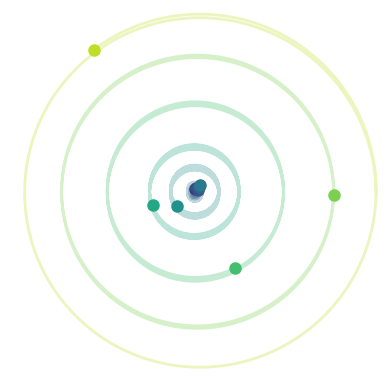

In [2]:
def update_plot(frame):
    plt.cla()  # Clear current plot
    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    for i in range(N):
        plt.plot(data[:frame+1, i, 0], 
                 data[:frame+1, i, 1], 
                 color=plt.cm.viridis(i/N), alpha=0.3, linewidth=2)  # Plot previous positions with shading
        plt.plot(data[frame, i, 0], data[frame, i, 1], 'o', color=plt.cm.viridis(i/N), markersize=8)  # Plot current position
        plt.gca().set_aspect('equal', adjustable='box')
        plt.axis('off')  # Turn off axes
        
############################################################################################
############################################################################################
############################################################################################

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

N=10

datos=np.loadtxt('planetas_posiciones.txt')
data = np.zeros((datos.shape[0],N,2))
data[:,:,0]=datos[:,0::2]
data[:,:,1]=datos[:,1::2]

# Create a new figure and axis
fig, ax = plt.subplots()
 
# Create the animation
ani = animation.FuncAnimation(fig, update_plot, frames=int(datos.shape[0]*0.4), interval=1)

# Save the animation as a GIF file
ani.save('planet_movement.gif', writer='pillow')

# Show the animation (optional)
plt.show()
#for i in range(10):
    #plt.plot(data[:,i,0],data[:,i,1],'.')

Además, obtenemos unos archivos con varias constantes de la simulación: las energías potencial (ep.txt), cinética (ec.txt) y total (et.txt) junto al momento angular de todos los planetas (momentos.txt); también obtenemos aproximaciones a los periodos de cada planeta (periodos.txt).

A su vez, se pueden cambiar los datos intercambiando planetas entre ellos o añadiendo más cuerpos. En el siguiente código, se ha añadido la estrella Betelgeuse en el lugar del Sol, ignorando su radio pues entonces habría que eliminar varios planetas, aproximando su masa a 14 masas solares.

In [ ]:
def accel(m, r):
    """
    Función para calcular la aceleración tras cada paso h dados un vector de masas y la matriz 2x10 de posiciones
    """
    a[:,:]=0
    for i in range(10):
        for j in range(10):
            if i!=j:
                a[0,i]+=-(m[j]*(r[0,i]-r[0,j]))/(np.sqrt((r[0,i]-r[0,j])**2+(r[1,i]-r[1,j])**2)**3)
                a[1,i]+=-(m[j]*(r[1,i]-r[1,j]))/(np.sqrt((r[0,i]-r[0,j])**2+(r[1,i]-r[1,j])**2)**3)
    return a

def waux(v, a, h):
    w=np.zeros((2,10))
    """
    Función para calcular la matriz auxiliar 2x10 w tras cada paso h dados la matriz 2x10 de velocidades, la matriz 2x10 de aceleraciones y el propio paso temporal h
    """
    for i in range(10):
        w[:,i]=v[:,i]+h/2*a[:,i]
    return w

def vel(a, w, h):
    v=np.zeros((2,10))
    """
    Función para calcular la aceleración tras cada paso h dados la matriz 2x10 de aceleraciones, la matriz 2x10 auxiliar w y el propio paso temporal h
    """
    v=np.zeros((2,10))
    for i in range(10):
        v[:,i]=w[:,i]+h/2*a[:,i]
    return v

def pos(r, v, a, h):
    """
    Función para calcular las posiciones tras cada paso h dados la matriz 2x10 de posiciones, la matriz 2x10 de velocidades, la matriz 2x10 de aceleraciones y el propio paso 
    temporal h
    """
    for i in range(10):
        r[:,i]+=h*v[:,i]+h**2/2*a[:,i]
    return r

def Energias(m, r, v):
    """
    Función para calcular la energía total del sistema tras cada paso h dados el vector de masas, la matriz 2x10 de posiciones y la matriz 2x10 de velocidades
    """
    Ec=0
    Ep=0
    for i in range(10):
        Ec+=0.5*(m[i])*(v[0,i]**2+v[1,i]**2)
        for j in range(10):
            if i!=j:
                Ep+=-(m[i])/(np.sqrt(r[0,i]**2+r[1,i]**2))
    Et=Ec+Ep
    return Ec, Ep, Et

###############################################################################################################################################################################
###############################################################################################################################################################################
###############################################################################################################################################################################

import numpy as np

G=6.67392e-11           #Constante gravitación universal en N*m**2/kg**2
c=1.496e11              #Distancia Tierra-Sol en m
MS=1.99e30              #Masa solar en kg

posi=open('planetas_posiciones_betelgeuse.txt','w')
cin=open('ec_betelgeuse.txt','w')
pot=open('ep_betelgeuse.txt','w')
tot=open('et_betelgeuse.txt','w')
periodo=open('periodos_betelgeuse.txt','w')
momento=open('momentos_betelgeuse.txt','w')

"""
Inicializamos el vector masas reescalado
"""
m=np.zeros(10)          
m[0]=14                  #Sol (subíndice 0)
m[1]=0.33e24/MS         #Mercurio (subíndice 1)
m[2]=4.87e24/MS         #Venus (subíndice 2)
m[3]=5.97e24/MS         #Tierra (subíndice 3)
m[4]=0.642e24/MS        #Marte (subíndice 4)
m[5]=1899e24/MS         #Júpiter (subíndice 5)
m[6]=568e24/MS          #Saturno (subíndice 6)
m[7]=86.8e24/MS         #Urano (subíndice 7)
m[8]=102e24/MS          #Neptuno (subíndice 8)
m[9]=0.0125e24/MS       #Plutón (subíndice 9)

"""
Matriz posiciones reescalada: con filas acordes a coordenadas x e y de cada columna/planeta y colocamos estas posiciones en una matriz 2x10
"""
r=np.zeros((2,10)) 
r[0,0]=0
r[0,1]=57.9e9/c
r[0,2]=108.2e9/c
r[0,3]=1
r[0,4]=227.9e9/c
r[0,5]=778.6e9/c
r[0,6]=1433.5e9/c
r[0,7]=2872.5e9/c
r[0,8]=4495.1e9/c
r[0,9]=5870e9/c
r[1,:]=0

for i in range(10):
  posi.write(f'{r[0,i]}\t{r[1,i]}\t')
posi.write("\n")

"""
Matriz velocidad reescalada: con filas acordes a componentes v_x y v_y de cada columna/planeta

Vector auxiliar w
"""
v=np.zeros((2,10)) 
v[0,:]=0
v[1,0]=1e-50
v[1,1]=(47.9e3/c)/(np.sqrt((G*MS)/c**3))
v[1,2]=(35e3/c)/(np.sqrt((G*MS)/c**3))
v[1,3]=(29.8e3/c)/(np.sqrt((G*MS)/c**3))
v[1,4]=(24.1e3/c)/(np.sqrt((G*MS)/c**3))
v[1,5]=(13.1e3/c)/(np.sqrt((G*MS)/c**3))
v[1,6]=(9.7e3/c)/(np.sqrt((G*MS)/c**3))
v[1,7]=(6.8e3/c)/(np.sqrt((G*MS)/c**3))
v[1,8]=(5.4e3/c)/(np.sqrt((G*MS)/c**3))
v[1,9]=(4.7e3/c)/(np.sqrt((G*MS)/c**3))

w=np.zeros((2,10))

"""
Matriz aceleración: con filas acordes a componentes a_x y a_y de cada columna/planeta
"""
a=np.zeros((2,10)) 

"""
Indicamos el paso temporal h  y creamos un vector para guardar más tarde los periodos
"""
h=0.0001
T=np.zeros(10)

"""
Calculamos la energía total en el instante 0, la energía cinética, la energíapotencial y la aceleración que sufre cada planeta por la acción gravitatoria de los otros cuerpos
"""
EC, EP, ET=Energias(m, r, v)
cin.write(f'{0}\t{EC}\n')
pot.write(f'{0}\t{EP}\n')
tot.write(f'{0}\t{ET}\n')

a=accel(m, r)

#T=periodo(r)
#print(T)

"""
Variable booleana auxiliar para calcular los periodos y variable auxiliar para guardar los datos cada cierto número de pasos
"""
pasaprimercuadrante=np.array([False,False,False,False,False,False,False,False,False,False],dtype=bool)
vez=np.ones(10)

pasos=0

"""
Empezamos los cálculos
"""
for t in np.arange(0, 5e3, h):
    #print(t)
    """
    Este bucle nos permitirá recoger de forma aproximada los periodos de los planetas
    """
    for i in range(10):
        if r[0,i]<=0:
            pasaprimercuadrante[i]=True
        if r[0,i]>0 and pasaprimercuadrante[i]==True and vez[i]==1:
            if r[1,i]>=0: 
                T[i]=58.1*(2*t-h)/2
                vez[i]+=1

    """
    Recalculamos las posiciones y la matriz auxiliar w
    """
    r=pos(r, v, a, h)
    w=waux(v, a, h)
    
    """
    Recalculamos la aceleración según las nuevas posiciones (posible mejora en términos de memoria)
    """
    a=accel(m, r)
    
    """
    Con las aceleraciones nuevas, recalculamos las velocidades
    """
    v=vel(a, w, h)
    
    """
    Recalculamos las energías
    """
    EC, EP, ET=Energias(m, r, v)

    """
    Aumentamos la variable para contar y guardamos las posiciones cada x pasos
    """
    pasos+=1
    if pasos%5000==0:
        for i in range(10):
            posi.write(f'{r[0,i]}\t{r[1,i]}\t')
            momento.write(f'{m[i]*(r[0,i]*v[1,i]-r[1,i]*v[0,i])}\t')
        cin.write(f'{t+h}\t{EC}\n')
        pot.write(f'{t+h}\t{EP}\n')
        tot.write(f'{t+h}\t{ET}\n')
        posi.write("\n")
        momento.write("\n")
for i in range(10):
    periodo.write(f'{T[i]}\t')
posi.close()
cin.close()
pot.close()
tot.close()
momento.close()
periodo.close()

De aquí podemos repetir el gif con el mismo código que antes.

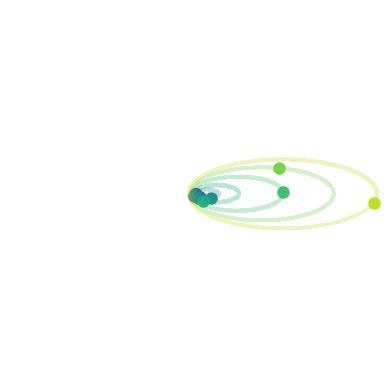

In [5]:
def update_plot(frame):
    plt.cla()  # Clear current plot
    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    for i in range(N):
        plt.plot(data[:frame+1, i, 0], 
                 data[:frame+1, i, 1], 
                 color=plt.cm.viridis(i/N), alpha=0.3, linewidth=2)  # Plot previous positions with shading
        plt.plot(data[frame, i, 0], data[frame, i, 1], 'o', color=plt.cm.viridis(i/N), markersize=8)  # Plot current position
        plt.gca().set_aspect('equal', adjustable='box')
        plt.axis('off')  # Turn off axes
        
############################################################################################
############################################################################################
############################################################################################

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

N=10

datos=np.loadtxt('planetas_posiciones_betelgeuse.txt')
data = np.zeros((datos.shape[0],N,2))
data[:,:,0]=datos[:,0::2]
data[:,:,1]=datos[:,1::2]

# Create a new figure and axis
fig, ax = plt.subplots()
 
# Create the animation
ani = animation.FuncAnimation(fig, update_plot, frames=int(datos.shape[0]*0.4), interval=1)

# Save the animation as a GIF file
ani.save('planet_movement_betelgeuse.gif', writer='pillow')

# Show the animation (optional)
plt.show()
#for i in range(10):
    #plt.plot(data[:,i,0],data[:,i,1],'.')

Aquí vemos claramente que, debido a la nueva estrella los planetas rocosos son atraídos de manera que parecen ser consumidos por la estrella mientras que Otros planetas se limitan a trazar elípticas con los focos muy alejados del centro de la misma, debido de nuevo a la nueva masa y seguramente absorbidos junto al resto si se dejase evolucionar el suficiente tiempo.  